<a href="https://colab.research.google.com/github/seelasairani7730-wq/Machine-Learning-Portfolio/blob/main/04_Decision_Tree/Car%20Evaluation%20Classification/Car_Evaluation_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Evaluation Classification using Decision Tree

## Project Overview

This project uses a **Decision Tree Classifier** to predict the overall evaluation of a car based on its buying price, maintenance cost, number of doors, passenger capacity, luggage boot size, and safety level.

The project demonstrates how Decision Trees can learn interpretable decision rules from categorical features.

## Problem Statement

The objective is to classify cars into different evaluation categories based on their characteristics.

The model predicts whether a car is:

* Unacceptable
* Acceptable
* Good
* Very Good

## Machine Learning Algorithm

**Decision Tree Classifier**

A Decision Tree makes predictions by repeatedly splitting the dataset based on feature values. This creates a tree-like structure of decision rules that can be visualized and interpreted.

## Dataset

The project uses the **Car Evaluation dataset**, which contains information about cars based on their:

* Buying price
* Maintenance price
* Number of doors
* Passenger capacity
* Luggage boot size
* Safety level

## Project Workflow

1. Import required libraries
2. Load the dataset
3. Understand the dataset
4. Check missing values and duplicates
5. Perform Exploratory Data Analysis
6. Analyze target classes
7. Prepare features and target
8. Encode categorical features
9. Split the dataset
10. Train the Decision Tree model
11. Tune hyperparameters
12. Evaluate model performance
13. Visualize the Decision Tree
14. Analyze feature importance
15. Save the trained model


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(
    url,
    names=columns
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1728, 7)


In [3]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1728, 7)

Column names:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

Data types:
buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Duplicate rows: 0


Class distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


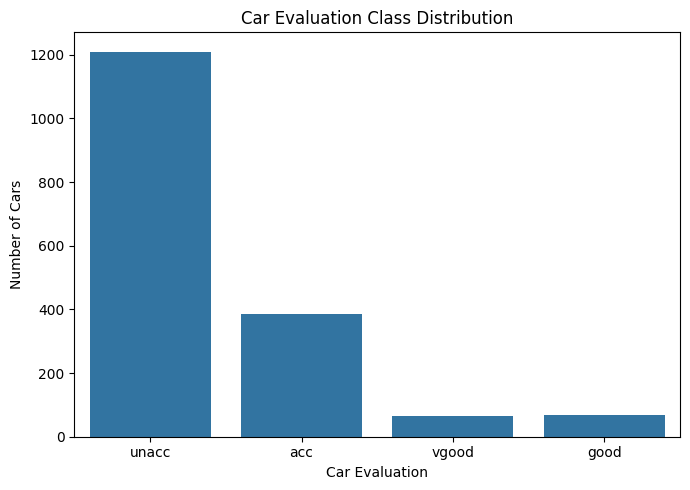

In [5]:
print("Class distribution:")
print(df["class"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Car Evaluation Class Distribution")
plt.xlabel("Car Evaluation")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

In [6]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


buying:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

maint:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

doors:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

persons:
persons
2       576
4       576
more    576
Name: count, dtype: int64

lug_boot:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

safety:
safety
low     576
med     576
high    576
Name: count, dtype: int64

class:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [7]:
X = df.drop("class", axis=1)
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Features shape: (1728, 6)
Target shape: (1728,)

Features:
  buying  maint doors persons lug_boot safety
0  vhigh  vhigh     2       2    small    low
1  vhigh  vhigh     2       2    small    med
2  vhigh  vhigh     2       2    small   high
3  vhigh  vhigh     2       2      med    low
4  vhigh  vhigh     2       2      med    med

Target:
0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object


In [8]:
X = df.drop("class", axis=1)
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Features shape: (1728, 6)
Target shape: (1728,)

Features:
  buying  maint doors persons lug_boot safety
0  vhigh  vhigh     2       2    small    low
1  vhigh  vhigh     2       2    small    med
2  vhigh  vhigh     2       2    small   high
3  vhigh  vhigh     2       2      med    low
4  vhigh  vhigh     2       2      med    med

Target:
0    unacc
1    unacc
2    unacc
3    unacc
4    unacc
Name: class, dtype: object


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (1382, 6)
Testing set: (346, 6)

Training class distribution:
class
unacc    968
acc      307
good      55
vgood     52
Name: count, dtype: int64

Testing class distribution:
class
unacc    242
acc       77
good      14
vgood     13
Name: count, dtype: int64


In [10]:
categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [11]:
dt_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [12]:
y_pred = dt_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Decision Tree Accuracy:", accuracy)
print("Baseline Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Decision Tree Accuracy: 0.9739884393063584
Baseline Accuracy (%): 97.39884393063583

Classification Report:
              precision    recall  f1-score   support

         acc       0.96      0.92      0.94        77
        good       0.88      1.00      0.93        14
       unacc       0.98      1.00      0.99       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.97       346
   macro avg       0.95      0.94      0.95       346
weighted avg       0.97      0.97      0.97       346



In [13]:
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best Cross-Validation Accuracy:
0.9674383927169989


In [14]:
best_dt_model = grid_search.best_estimator_

y_pred = best_dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Best Decision Tree Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Decision Tree Test Accuracy: 0.9739884393063584
Test Accuracy (%): 97.39884393063583

Classification Report:
              precision    recall  f1-score   support

         acc       0.96      0.92      0.94        77
        good       0.88      1.00      0.93        14
       unacc       0.98      1.00      0.99       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.97       346
   macro avg       0.95      0.94      0.95       346
weighted avg       0.97      0.97      0.97       346



Confusion Matrix:
[[ 71   2   4   0]
 [  0  14   0   0]
 [  1   0 241   0]
 [  2   0   0  11]]


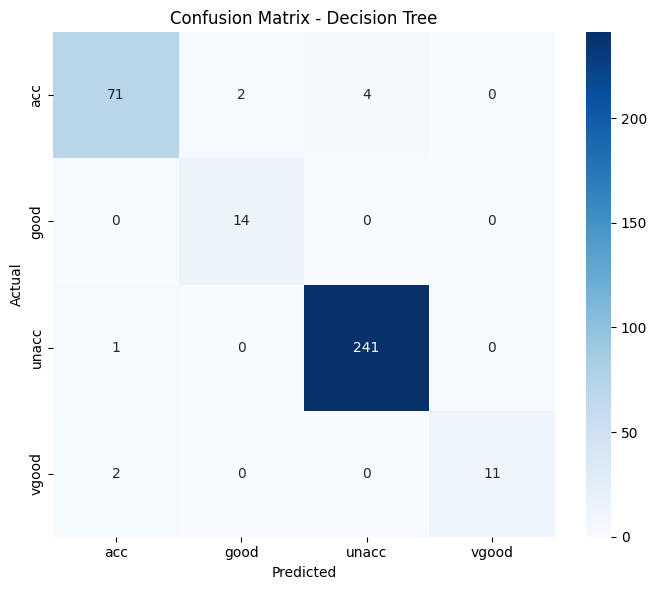

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["acc", "good", "unacc", "vgood"],
    yticklabels=["acc", "good", "unacc", "vgood"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

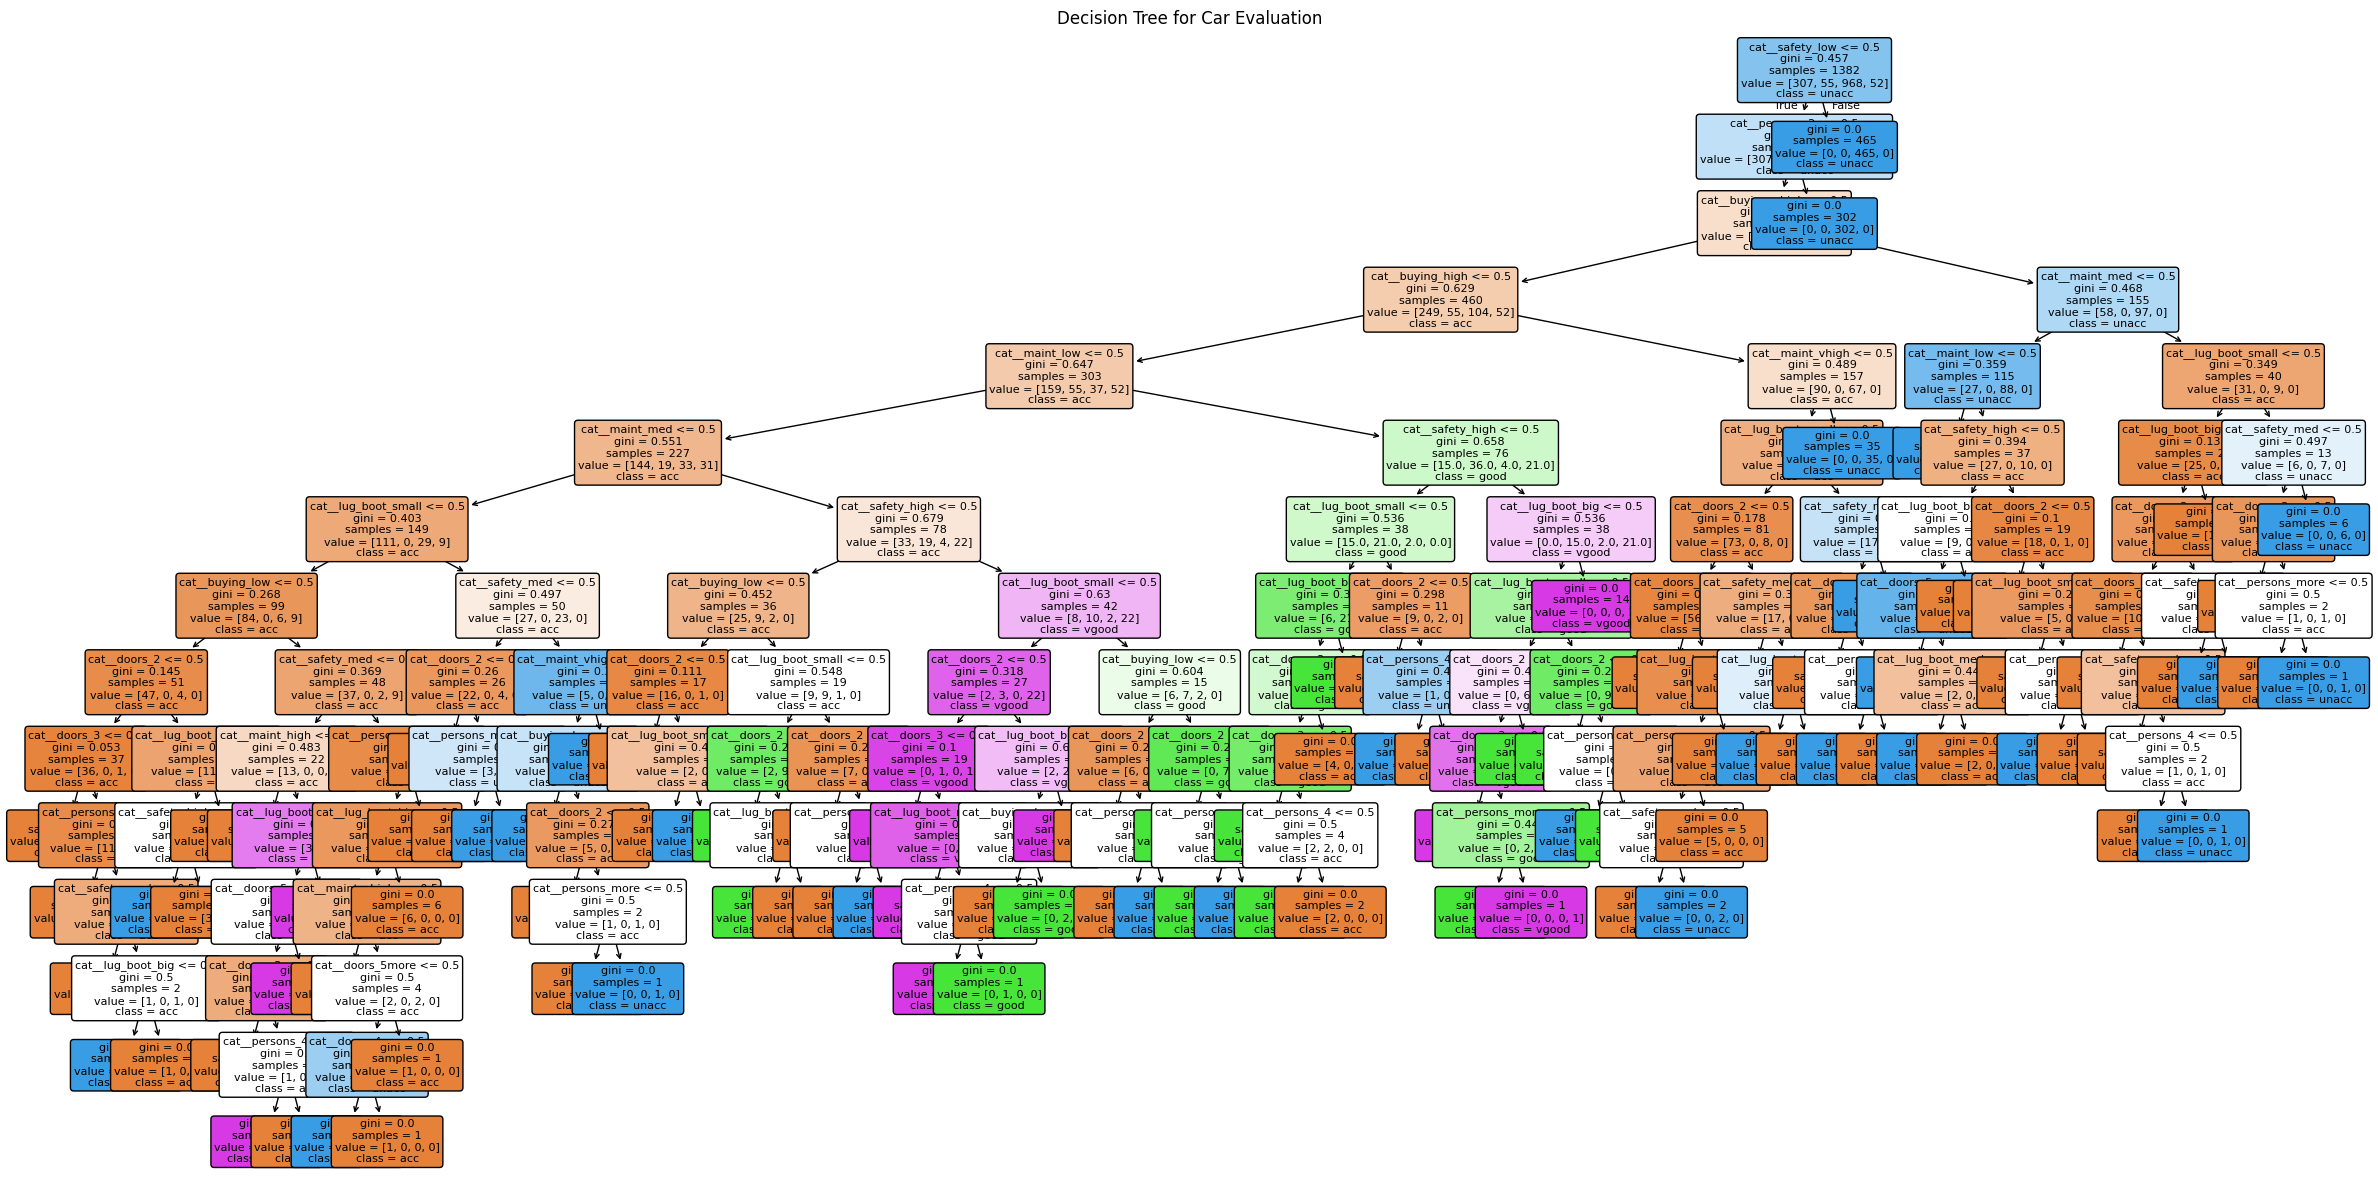

In [16]:
plt.figure(figsize=(24, 12))

plot_tree(
    best_dt_model.named_steps["classifier"],
    feature_names=best_dt_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=best_dt_model.named_steps["classifier"].classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Car Evaluation")

plt.tight_layout()
plt.show()

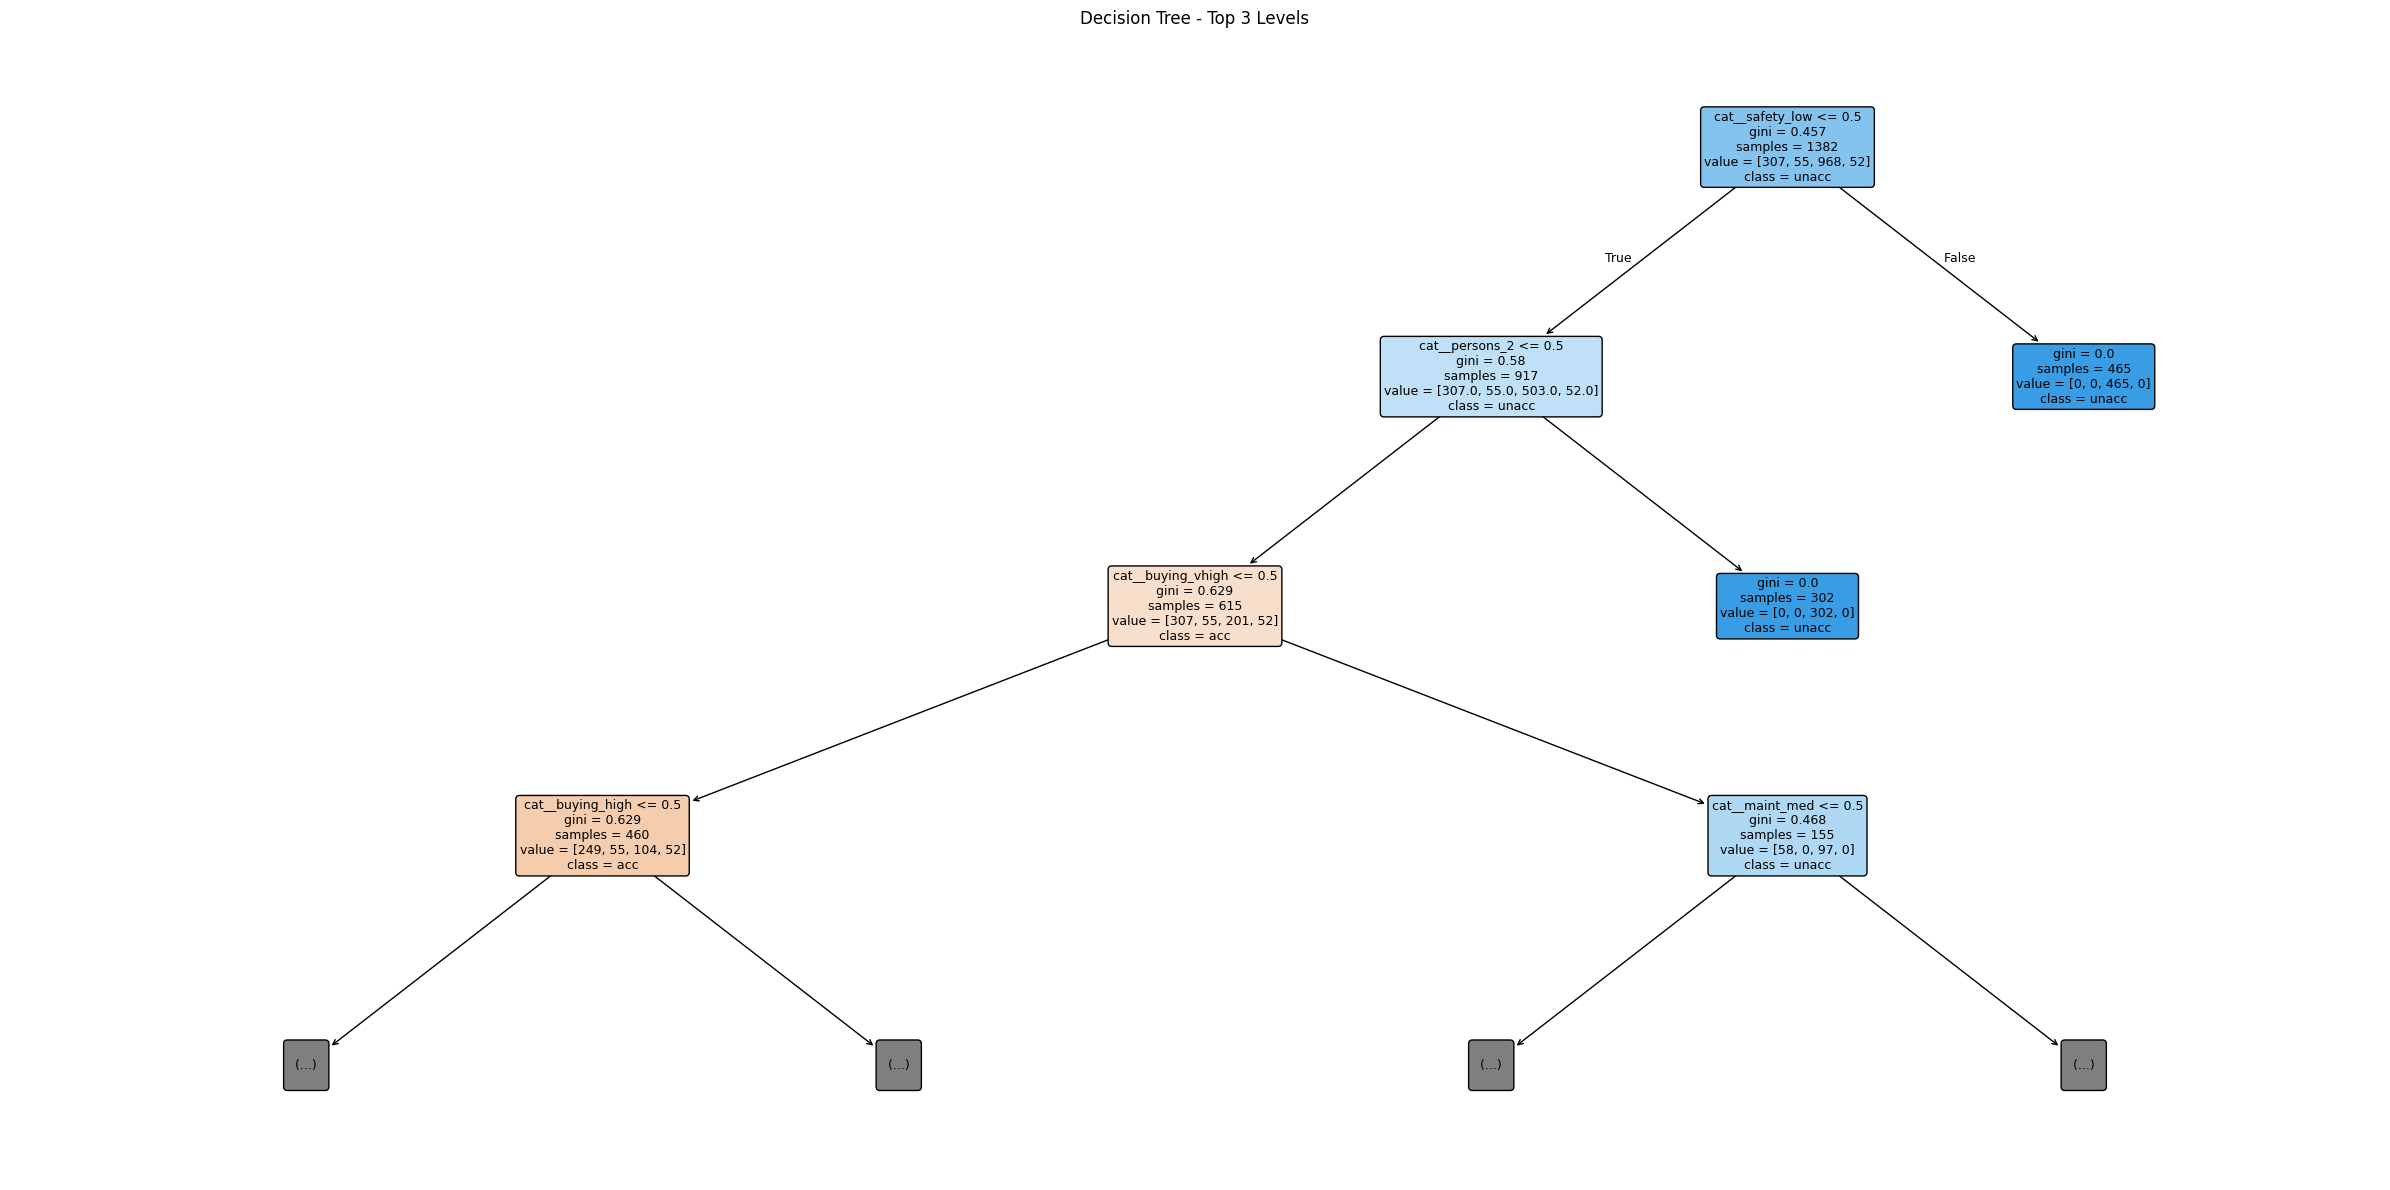

In [17]:
plt.figure(figsize=(24, 12))

plot_tree(
    best_dt_model.named_steps["classifier"],
    feature_names=best_dt_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=best_dt_model.named_steps["classifier"].classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree - Top 3 Levels")

plt.tight_layout()
plt.show()

In [18]:
classifier = best_dt_model.named_steps["classifier"]
preprocessor = best_dt_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(10))

                Feature  Importance
12       cat__persons_2    0.230072
19      cat__safety_low    0.157644
17  cat__lug_boot_small    0.082438
5        cat__maint_low    0.075773
20      cat__safety_med    0.063853
7      cat__maint_vhigh    0.051521
15    cat__lug_boot_big    0.047748
6        cat__maint_med    0.046280
18     cat__safety_high    0.041452
8          cat__doors_2    0.041116


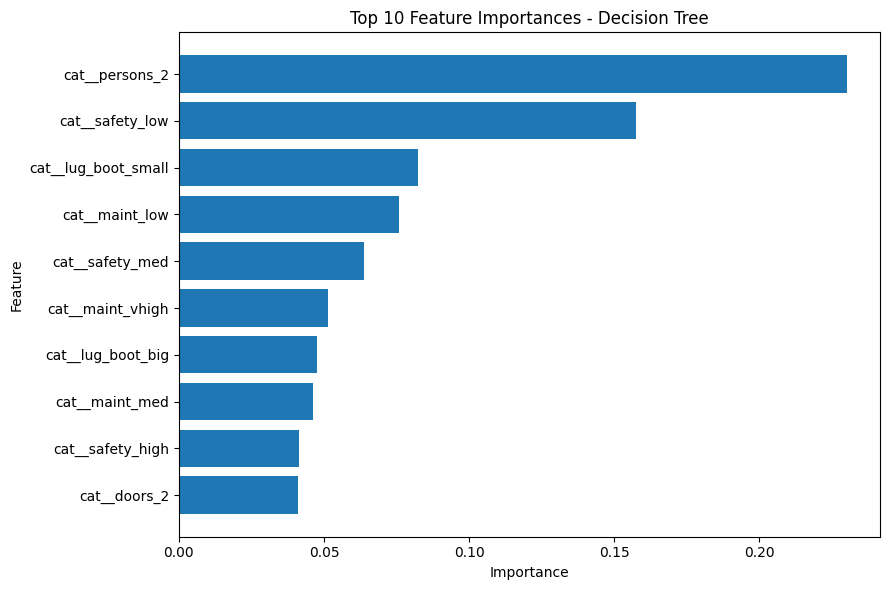

In [19]:
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

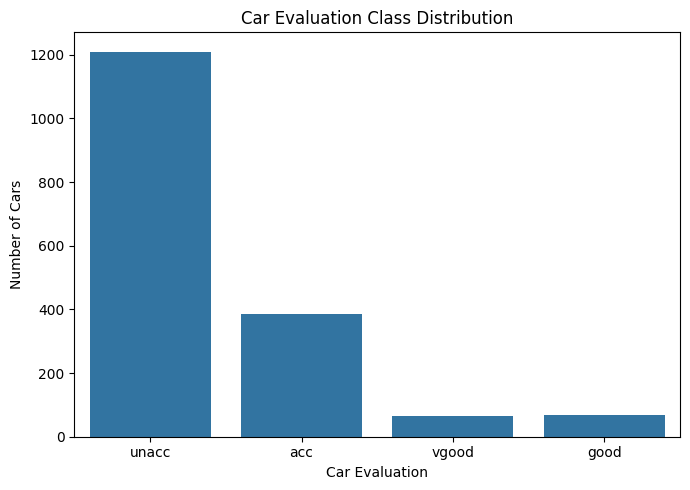

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Car Evaluation Class Distribution")
plt.xlabel("Car Evaluation")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.savefig("car_class_distribution.png", dpi=300)
plt.show()

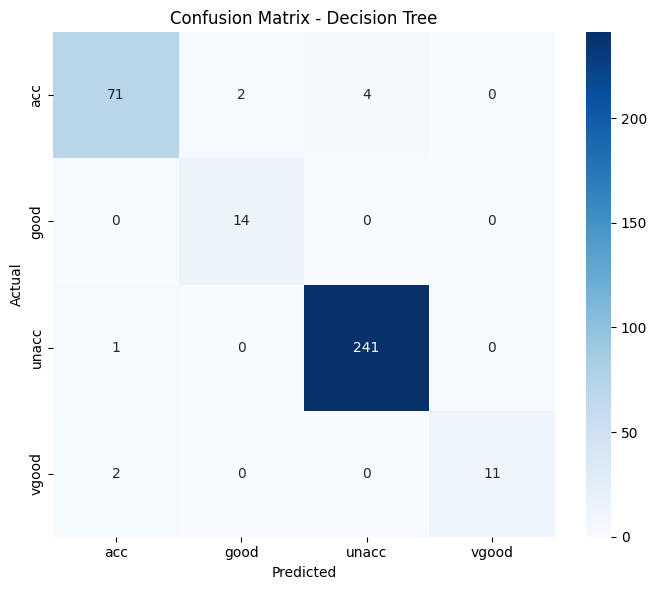

In [21]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["acc", "good", "unacc", "vgood"],
    yticklabels=["acc", "good", "unacc", "vgood"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

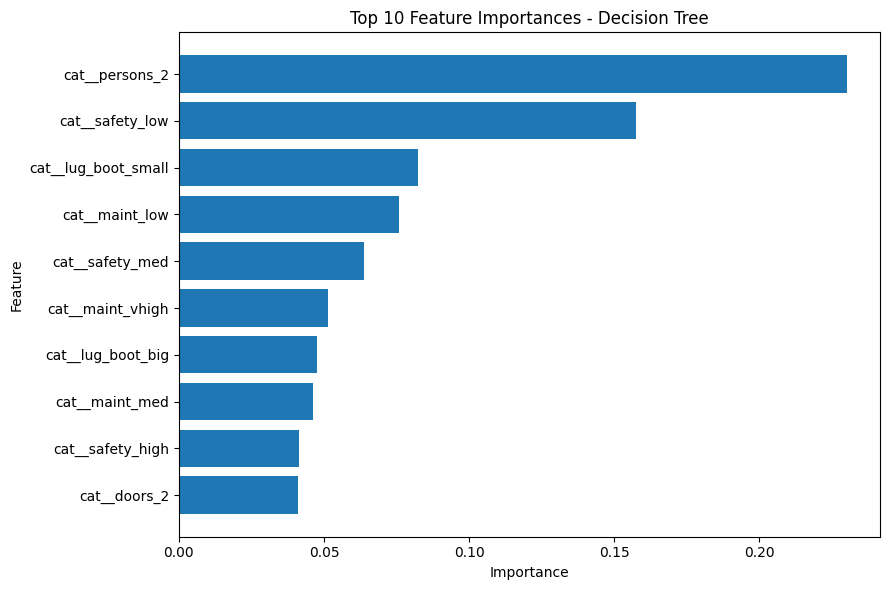

In [22]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

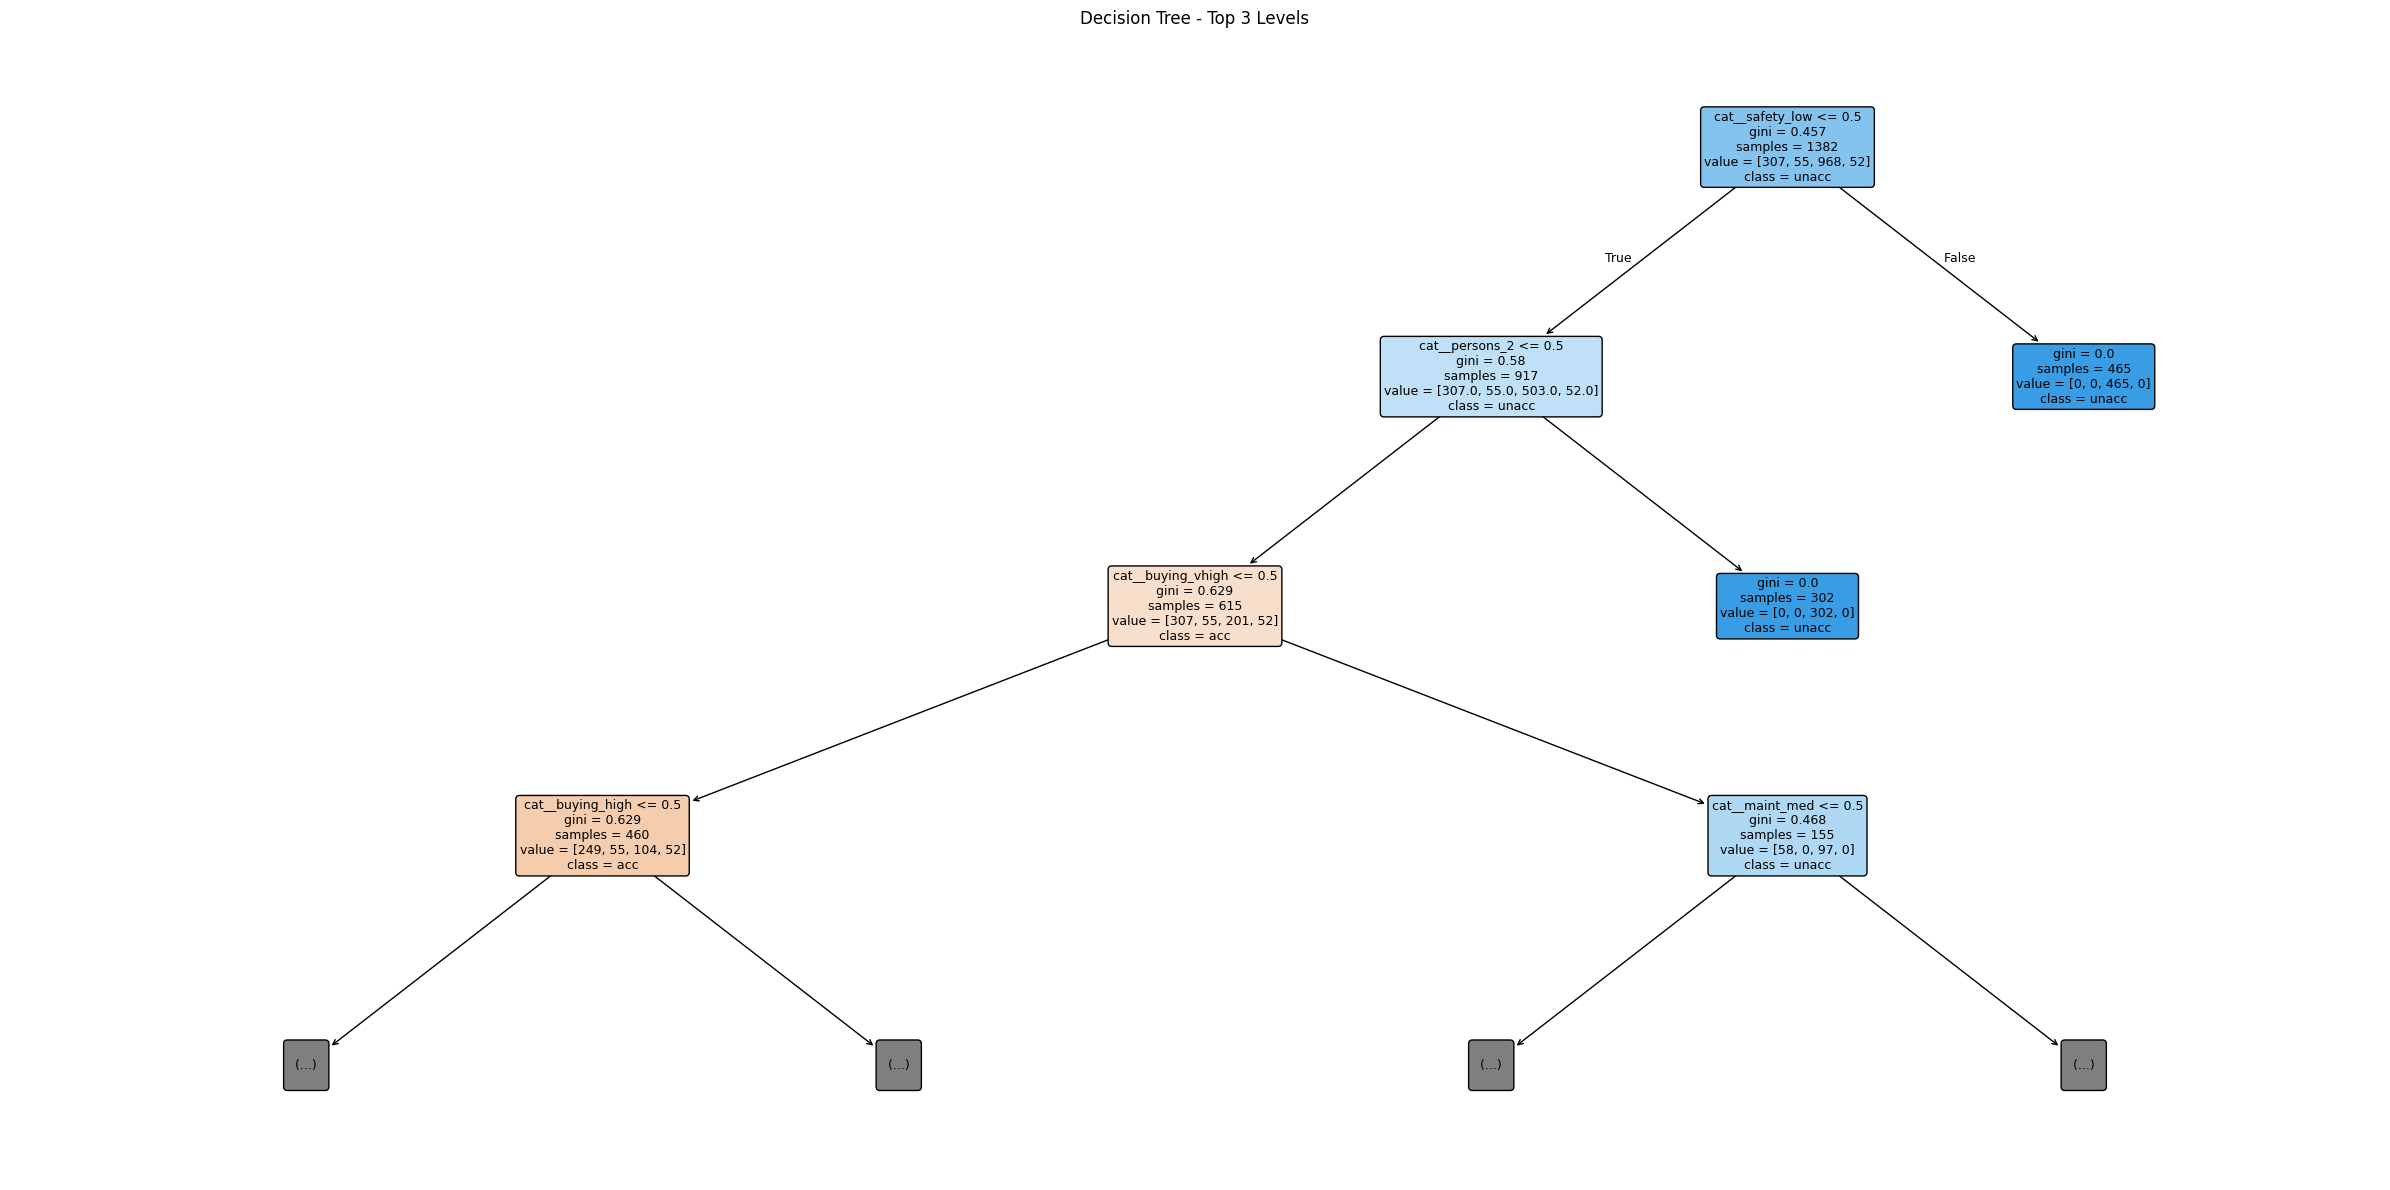

In [23]:
plt.figure(figsize=(24, 12))

plot_tree(
    best_dt_model.named_steps["classifier"],
    feature_names=best_dt_model.named_steps["preprocessor"].get_feature_names_out(),
    class_names=best_dt_model.named_steps["classifier"].classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree - Top 3 Levels")

plt.tight_layout()

plt.savefig("decision_tree_top3.png", dpi=300)

plt.show()

In [24]:
joblib.dump(
    best_dt_model,
    "decision_tree_car_evaluation.pkl"
)

print("Decision Tree pipeline saved successfully!")

Decision Tree pipeline saved successfully!


In [25]:
loaded_dt = joblib.load("decision_tree_car_evaluation.pkl")

loaded_pred = loaded_dt.predict(X_test)

print("Predictions match:", np.array_equal(y_pred, loaded_pred))

Predictions match: True
